In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "************"

!pip install kaggle -q
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [ ]:
!pip install --upgrade kaggle -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 23.0 MB/s eta 0:00:00


In [ ]:
!kaggle competitions download -c cifar-10
#!unzip -q cifar-10.zip -d cifar10_data

100% 715M/715M [00:34<00:00, 22.0MB/s]



In [ ]:
!unzip -q cifar-10.zip -d cifar10_data

In [ ]:
!pip install py7zr -q
import py7zr

with py7zr.SevenZipFile('cifar10_data/train.7z', mode='r') as z:
    z.extractall('cifar10_data')

with py7zr.SevenZipFile('cifar10_data/test.7z', mode='r') as z:
    z.extractall('cifar10_data')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 17.2 MB/s eta 0:00:00


In [ ]:
#ls cifar10_data/test/

In [ ]:
import pandas as pd
pd.read_csv('cifar10_data/trainLabels.csv')

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile
...,...,...
49995,49996,bird
49996,49997,frog
49997,49998,truck
49998,49999,automobile


In [ ]:

pd.read_csv('cifar10_data/sampleSubmission.csv')

,id,label
0,1,cat
1,2,cat
2,3,cat
3,4,cat
4,5,cat
...,...,...
299995,299996,cat
299996,299997,cat
299997,299998,cat
299998,299999,cat


In [ ]:
"""
per_neuron_drop_dense.py

A Dense layer variant that applies dropout-style or Gaussian noise
masking directly to individual weight *connections* (i.e. per input-unit
pair), rather than to whole activations as standard `Dropout` does.

This is conceptually related to DropConnect (Wan et al., 2013,
"Regularization of Neural Networks using DropConnect"), with two modes:

- stir_type="drop":     a Bernoulli mask zeroes out individual weights,
                        scaled by 1 / (1 - drop_rate) to preserve the
                        expected activation magnitude (inverted dropout).
- stir_type="gaussian": weights are perturbed by multiplicative Gaussian
                        noise with mean 1 and a variance chosen so that
                        it matches the variance of the Bernoulli mask
                        above, for a comparable regularization strength.

The mask can either be:
- resampled fresh on every forward pass during training (fixed_mask=False,
  the default), which is closest to standard DropConnect, or
- sampled once at layer build time and reused for every forward pass
  (fixed_mask=True), which turns the layer into a fixed sparse / noisy
  sub-network.

Author: (your name here)
License: MIT
"""

from __future__ import annotations

import tensorflow as tf
from tensorflow.keras import layers

_VALID_STIR_TYPES = ("drop", "gaussian")


class PerNeuronDropDense(layers.Layer):
    """Dense layer with per-connection dropout or Gaussian weight noise.

    Args:
        units: Positive integer, dimensionality of the output space.
        drop_rate: Float in [0, 1). Fraction of weight connections dropped
            (stir_type="drop") or the noise-variance driver
            (stir_type="gaussian"). 0.0 disables the effect entirely.
        fixed_mask: If True, a single mask/noise tensor is sampled once at
            build time and reused on every call (in both training and
            inference). If False (default), a new mask is sampled on every
            training-time forward pass, and the layer behaves as a plain
            Dense layer at inference time.
        stir_type: Either "drop" (Bernoulli mask) or "gaussian"
            (multiplicative Gaussian noise).
        activation: Activation function to apply to the output, or None.
        **kwargs: Standard `keras.layers.Layer` keyword arguments.

    Input shape:
        2D tensor `(batch, input_dim)` or 3D tensor `(batch, time, input_dim)`.

    Output shape:
        2D tensor `(batch, units)` or 3D tensor `(batch, time, units)`.

    Example:
        >>> layer = PerNeuronDropDense(64, drop_rate=0.2, stir_type="drop")
        >>> x = tf.random.normal((32, 128))
        >>> y = layer(x, training=True)
        >>> y.shape
        TensorShape([32, 64])
    """

    def __init__(
        self,
        units: int,
        drop_rate: float = 0.2,
        fixed_mask: bool = False,
        stir_type: str = "drop",
        activation=None,
        **kwargs,
    ):
        super().__init__(**kwargs)

        if units <= 0:
            raise ValueError(f"units must be a positive integer. Got {units}.")
        if not (0.0 <= drop_rate < 1.0):
            raise ValueError(f"drop_rate must be in [0, 1). Got {drop_rate}.")

        stir_type = stir_type.lower()
        if stir_type not in _VALID_STIR_TYPES:
            raise ValueError(
                f"stir_type must be one of {_VALID_STIR_TYPES}. Got {stir_type!r}."
            )

        self.units = int(units)
        self.drop_rate = float(drop_rate)
        self.fixed_mask = bool(fixed_mask)
        self.stir_type = stir_type
        self.activation = tf.keras.activations.get(activation)

        self.kernel = None
        self.bias = None
        self.fixed_mask_value = None

    def build(self, input_shape):
        last_dim = int(input_shape[-1])

        self.kernel = self.add_weight(
            name="kernel",
            shape=(last_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.bias = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
        )

        if self.fixed_mask:
            self.fixed_mask_value = self.add_weight(
                name="fixed_mask_value",
                shape=(last_dim, self.units),
                initializer=self._make_mask_initializer(),
                trainable=False,
            )

        super().build(input_shape)

    def _make_mask_initializer(self):
        """Returns a Keras-compatible initializer that samples one static
        mask / noise tensor, used only when fixed_mask=True."""

        def initializer(shape, dtype=None):
            dtype = dtype or tf.float32

            if self.stir_type == "drop":
                if self.drop_rate == 0.0:
                    return tf.ones(shape, dtype=dtype)
                keep = tf.cast(tf.random.uniform(shape) > self.drop_rate, dtype)
                return keep / (1.0 - self.drop_rate)

            # stir_type == "gaussian"
            if self.drop_rate == 0.0:
                return tf.ones(shape, dtype=dtype)
            stddev = tf.cast(
                tf.sqrt(self.drop_rate / (1.0 - self.drop_rate)), dtype
            )
            return tf.random.normal(shape, mean=1.0, stddev=stddev, dtype=dtype)

        return initializer

    def _sample_dynamic_mask(self, mask_shape, dtype):
        """Samples a fresh per-batch-element mask / noise tensor."""
        if self.stir_type == "drop":
            keep = tf.cast(tf.random.uniform(mask_shape) > self.drop_rate, dtype)
            return keep / (1.0 - self.drop_rate)

        # stir_type == "gaussian"
        eps = 1e-6
        stddev = tf.sqrt(
            tf.maximum(self.drop_rate, eps) / tf.maximum(1.0 - self.drop_rate, eps)
        )
        stddev = tf.cast(stddev, dtype)
        return tf.random.normal(mask_shape, mean=1.0, stddev=stddev, dtype=dtype)

    def call(self, inputs, training=None, return_masks: bool = False):
        dtype = inputs.dtype
        rank = inputs.shape.rank
        if rank not in (2, 3):
            raise ValueError(
                f"PerNeuronDropDense only supports rank-2 or rank-3 inputs, "
                f"got rank {rank}."
            )

        batch = tf.shape(inputs)[0]
        input_dim = tf.shape(inputs)[-1]

        if training is None:
            training = False

        # gate == 1 -> apply mask/noise to the kernel; gate == 0 -> plain Dense.
        # A fixed mask is always "active" (train and inference); a dynamic
        # mask is only active during training.
        if isinstance(training, bool):
            gate = tf.constant(float(training or self.fixed_mask), dtype=dtype)
        else:
            gate = tf.cast(tf.logical_or(training, self.fixed_mask), dtype)

        if self.fixed_mask:
            mask = tf.tile(tf.expand_dims(self.fixed_mask_value, 0), [batch, 1, 1])
        else:
            mask = self._sample_dynamic_mask((batch, input_dim, self.units), dtype)

        effective_kernel = gate * (mask * self.kernel) + (1.0 - gate) * self.kernel

        if rank == 2:
            output = tf.einsum("bi,biu->bu", inputs, effective_kernel)
        else:  # rank == 3
            output = tf.einsum("bti,biu->btu", inputs, effective_kernel)

        output = output + self.bias

        if self.activation is not None:
            output = self.activation(output)

        return (output, mask) if return_masks else output

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.units,)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "units": self.units,
                "drop_rate": self.drop_rate,
                "fixed_mask": self.fixed_mask,
                "stir_type": self.stir_type,
                "activation": tf.keras.activations.serialize(self.activation),
            }
        )
        return config

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, initializers

class PerNeuronDropDense(layers.Layer):
    def __init__(self, units, drop_rate=0.2, fixed_mask=False, stir_type="drop", activation=None, **kwargs):
        """
        Args:
          units: number of output neurons.
          drop_rate: dropout probability.
          fixed_mask: if True, the dropout/noise mask is computed once and reused.
          strirType: either 'drop' for standard dropout or 'gaussian' for Gaussian dropout.
          activation: activation function.
        """
        super(PerNeuronDropDense, self).__init__(**kwargs)
        self.units = units
        self.drop_rate = drop_rate
        self.fixed_mask = fixed_mask
        self.stir_type = stir_type.lower()  # normalize
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        last_dim = input_shape[-1]
        self.kernel = self.add_weight(
            name="kernel",
            shape=(last_dim, self.units),
            initializer=initializers.GlorotUniform(),
            trainable=True
        )
        self.bias = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer="zeros",
            trainable=True
        )

        if self.fixed_mask:
            # Define a custom initializer for the fixed mask.
            def fixed_mask_initializer(shape, dtype=None):
                if self.stir_type == "drop":
                    mask = tf.cast(tf.random.uniform(shape) > self.drop_rate, dtype)
                    return mask / (1.0 - self.drop_rate)
                elif self.stir_type == "gaussian":
                    stddev = tf.sqrt(self.drop_rate / (1 - self.drop_rate))
                    return tf.random.normal(shape, mean=1.0, stddev=stddev, dtype=dtype)
                else:
                    raise ValueError("stir_type must be either 'drop' or 'gaussian'.")

            # Store the fixed mask as a non-trainable weight.
            self.fixed_mask_value = self.add_weight(
                name="fixed_mask_value",
                shape=(last_dim, self.units),
                initializer=fixed_mask_initializer,
                trainable=False
            )
        else:
            self.fixed_mask_value = None

        super(PerNeuronDropDense, self).build(input_shape)

    def call(self, inputs, training=False, return_masks=False):
        rank = inputs.shape.rank  # 2 for images, 3 for sequences (NLP)
        input_shape = tf.shape(inputs)
        batch = input_shape[0]
        input_dim = input_shape[-1]

        # --- Generate or retrieve dropout mask ---
        if training or self.fixed_mask:
            if self.fixed_mask and self.fixed_mask_value is not None:
                # Tile the fixed mask along the batch dimension.
                mask = tf.expand_dims(self.fixed_mask_value, axis=0)  # shape: (1, input_dim, units)
                mask = tf.tile(mask, [batch, 1, 1])  # shape: (batch, input_dim, units)
            else:
                # Create a new dynamic mask.
                mask_shape = tf.stack([batch, input_dim, self.units])
                if self.stir_type == "drop":
                    mask = tf.cast(tf.random.uniform(mask_shape) > self.drop_rate, inputs.dtype)
                    mask = mask / (1.0 - self.drop_rate)
                elif self.stir_type == "gaussian":
                    stddev = tf.sqrt(self.drop_rate / (1 - self.drop_rate))
                    mask = tf.random.normal(mask_shape, mean=1.0, stddev=stddev, dtype=inputs.dtype)
                else:
                    raise ValueError("stir_type must be either 'drop' or 'gaussian'.")
        else:
            mask = None

        # --- Compute effective kernel and output ---
        if mask is None:
            if rank == 2:
                output = tf.matmul(inputs, self.kernel)
            elif rank == 3:
                output = tf.tensordot(inputs, self.kernel, axes=[[2], [0]])
            else:
                raise ValueError("Unsupported input rank.")
        else:
            # Multiply kernel by mask to get an effective kernel per sample.
            effective_kernel = mask * self.kernel  # shape: (batch, input_dim, units)
            if rank == 2:
                # For each sample, compute dot product.
                output = tf.einsum('bi,biu->bu', inputs, effective_kernel)
            elif rank == 3:
                output = tf.einsum('bti,biu->btu', inputs, effective_kernel)
            else:
                raise ValueError("Unsupported input rank.")

        output = output + self.bias
        if self.activation:
            output = self.activation(output)

        if return_masks:
            return output, mask
        return output

    def get_config(self):
        config = super(PerNeuronDropDense, self).get_config()
        config.update({
            "units": self.units,
            "drop_rate": self.drop_rate,
            "fixed_mask": self.fixed_mask,
            "stir_type": self.stir_type,
            "activation": tf.keras.activations.serialize(self.activation)
        })
        return config

# PerNeuronDropDense — CIFAR-10 Experiments

This notebook benchmarks the `PerNeuronDropDense` layer against a standard
`Dense + Dropout` baseline on CIFAR-10, using a small CNN feature extractor
and swapping only the classifier head.

Configurations compared:

1. **Baseline** — `Dense` + `Dropout`
2. **PerNeuronDropDense (drop)** — Bernoulli connection masking
3. **PerNeuronDropDense (gaussian)** — multiplicative Gaussian weight noise
4. **PerNeuronDropDense (fixed mask)** — a single frozen random sub-network

Each is trained for a few epochs on CIFAR-10 and compared on validation
accuracy/loss curves and final test accuracy.


In [ ]:
import os
import sys
import time

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Make the layer importable whether the notebook is run from the repo root
# or from inside notebook/
sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("."))

#from per_neuron_drop_dense import PerNeuronDropDense

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1. Load and preprocess CIFAR-10

In [ ]:
#(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

#x_train = x_train.astype("float32") / 255.0
#x_test = x_test.astype("float32") / 255.0
#y_train = y_train.squeeze()
#y_test = y_test.squeeze()

## Hold out a validation split from the training set
#val_split = 5000
#x_val, y_val = x_train[-val_split:], y_train[-val_split:]
#x_train, y_train = x_train[:-val_split], y_train[:-val_split]

#class_names = ["airplane", "automobile", "bird", "cat", "deer",
#               "dog", "frog", "horse", "ship", "truck"]

#print("train:", x_train.shape, "val:", x_val.shape, "test:", x_test.shape)


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import os

# --- Load training labels and build class mapping ---
labels_df = pd.read_csv('cifar10_data/trainLabels.csv')
class_names = sorted(labels_df['label'].unique())          # alphabetical, consistent order
label_map = {name: i for i, name in enumerate(class_names)}

# --- Build x_train / y_train from PNGs ---
n_train = len(labels_df)
x_train = np.zeros((n_train, 32, 32, 3), dtype=np.uint8)
y_train = np.zeros(n_train, dtype=np.int64)

for i, row in labels_df.iterrows():
    img = Image.open(f"cifar10_data/train/{row['id']}.png")
    x_train[i] = np.array(img)
    y_train[i] = label_map[row['label']]

# --- Build x_test from PNGs (no labels — sampleSubmission.csv is just a template) ---
sample_sub = pd.read_csv('cifar10_data/sampleSubmission.csv')
test_ids = sample_sub['id'].tolist()

n_test = len(test_ids)
x_test = np.zeros((n_test, 32, 32, 3), dtype=np.uint8)

for i, tid in enumerate(test_ids):
    img = Image.open(f"cifar10_data/test/{tid}.png")
    x_test[i] = np.array(img)

# --- Normalize ---
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# --- Hold out a validation split from training set ---
val_split = 5000
x_val, y_val = x_train[-val_split:], y_train[-val_split:]
x_train, y_train = x_train[:-val_split], y_train[:-val_split]

print("train:", x_train.shape, "val:", x_val.shape, "test:", x_test.shape)
print("class_names:", class_names)

train: (45000, 32, 32, 3) val: (5000, 32, 32, 3) test: (300000, 32, 32, 3)
class_names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


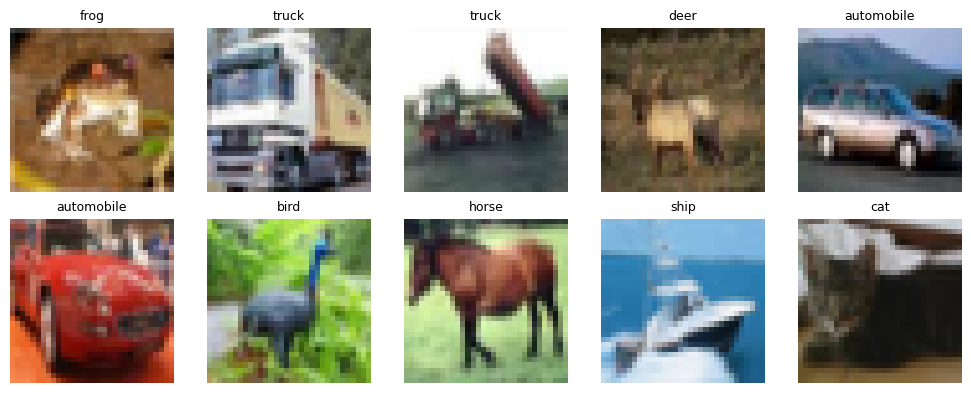

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Shared CNN feature extractor + swappable classifier head

All configurations share the same convolutional backbone; only the dense
classifier head changes, so any difference in results is attributable to
the head layer being tested.


In [ ]:
def build_backbone():
    """Convolutional feature extractor shared by every configuration."""
    inputs = tf.keras.Input(shape=(32, 32, 3))
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.Conv2D(32, 3, activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv2D(64, 3, activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Flatten()(x)
    return inputs, x


def build_model(head_fn, name):
    inputs, features = build_backbone()
    x = head_fn(features)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# --- Classifier heads under comparison -------------------------------

def head_baseline_dropout(x, drop_rate=0.2):
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(drop_rate)(x)
    return x


def head_drop(x, drop_rate=0.3):
    return PerNeuronDropDense(256, drop_rate=drop_rate, stir_type="drop",
                               activation="relu")(x)




def head_gaussian(x, drop_rate=0.3):
    return PerNeuronDropDense(256, drop_rate=drop_rate, stir_type="gaussian",
                               activation="relu")(x)


def head_fixed_mask(x, drop_rate=0.3):
    return PerNeuronDropDense(256, drop_rate=drop_rate, stir_type="drop",
                               fixed_mask=True, activation="relu")(x)





In [ ]:
CONFIGS = {

    "baseline_dropout": head_baseline_dropout,
    "per_neuron_drop": head_drop,
    "per_neuron_gaussian": head_gaussian,
    #"per_neuron_fixed_mask": head_fixed_mask,
}

## 3. Train each configuration

In [ ]:
EPOCHS = 50
BATCH_SIZE = 128

histories = {}
test_scores = {}

x_test, y_test=x_val, y_val
for name, head_fn in CONFIGS.items():
    print(f"\n=== Training: {name} ===")
    tf.random.set_seed(42)
    model = build_model(head_fn, name=name)

    start = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=2,
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name}: test_acc={test_acc:.4f}  test_loss={test_loss:.4f}  ({elapsed:.1f}s)")

    histories[name] = history.history
    test_scores[name] = {"test_acc": test_acc, "test_loss": test_loss, "train_time_s": elapsed}



=== Training: baseline_dropout ===
Epoch 1/50
352/352 - 15s - 44ms/step - accuracy: 0.3400 - loss: 1.8415 - val_accuracy: 0.4362 - val_loss: 1.5849
Epoch 2/50
352/352 - 1s - 4ms/step - accuracy: 0.4456 - loss: 1.5423 - val_accuracy: 0.4876 - val_loss: 1.4318
Epoch 3/50
352/352 - 1s - 4ms/step - accuracy: 0.4939 - loss: 1.4187 - val_accuracy: 0.5236 - val_loss: 1.3306
Epoch 4/50
352/352 - 1s - 4ms/step - accuracy: 0.5237 - loss: 1.3355 - val_accuracy: 0.5548 - val_loss: 1.2516
Epoch 5/50
352/352 - 1s - 4ms/step - accuracy: 0.5486 - loss: 1.2717 - val_accuracy: 0.5784 - val_loss: 1.2024
Epoch 6/50
352/352 - 1s - 4ms/step - accuracy: 0.5704 - loss: 1.2223 - val_accuracy: 0.5954 - val_loss: 1.1584
Epoch 7/50
352/352 - 1s - 4ms/step - accuracy: 0.5866 - loss: 1.1760 - val_accuracy: 0.6062 - val_loss: 1.1229
Epoch 8/50
352/352 - 1s - 4ms/step - accuracy: 0.6009 - loss: 1.1386 - val_accuracy: 0.6232 - val_loss: 1.0904
Epoch 9/50
352/352 - 1s - 4ms/step - accuracy: 0.6147 - loss: 1.1014 - val

## 4. Compare validation curves

In [ ]:
pd.DataFrame(histories['baseline_dropout']).sort_values('val_loss').head(5)

,accuracy,loss,val_accuracy,val_loss
29,0.784311,0.627519,0.7284,0.813404
30,0.789689,0.609990,0.7260,0.814105
33,0.801467,0.571429,0.7262,0.820992
27,0.768067,0.665083,0.7246,0.821074
31,0.792822,0.599953,0.7296,0.821181


In [ ]:
pd.DataFrame(histories['per_neuron_drop']).sort_values('val_loss').head(5)

,accuracy,loss,val_accuracy,val_loss
34,0.811311,0.551564,0.7462,0.769821
35,0.815178,0.539276,0.7512,0.770605
36,0.819022,0.526577,0.7512,0.771504
32,0.800067,0.578076,0.7452,0.772728
31,0.797978,0.591553,0.7438,0.774662


In [ ]:
pd.DataFrame(histories['per_neuron_gaussian']).sort_values('val_loss').head(5)

,accuracy,loss,val_accuracy,val_loss
37,0.817489,0.533863,0.7466,0.782081
33,0.799200,0.582250,0.7458,0.782817
35,0.811822,0.554225,0.7456,0.783276
31,0.792800,0.606202,0.7438,0.783295
34,0.801733,0.571951,0.7422,0.784775


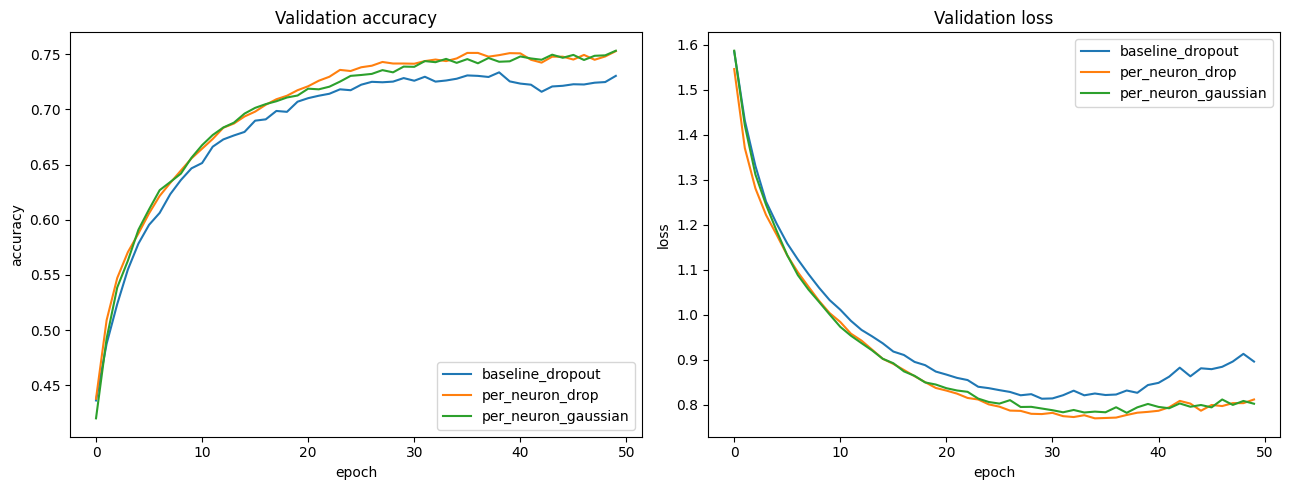

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, hist in histories.items():
    axes[0].plot(hist["val_accuracy"], label=name)
    axes[1].plot(hist["val_loss"], label=name)

axes[0].set_title("Validation accuracy")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("accuracy")
axes[0].legend()

axes[1].set_title("Validation loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## Run on Drop Rates

In [ ]:
def build_model(head_fn, name, drop_rate):
    inputs, features = build_backbone()

    x = head_fn(features, drop_rate=drop_rate)

    outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [ ]:
import os
import time
import pandas as pd
import tensorflow as tf

EPOCHS = 100          # allow early stopping to decide
BATCH_SIZE = 128

DROP_RATES = [0.1,0.2,0.3,0.4,0.5,0.6]

histories = {}
results = []

os.makedirs("checkpoints", exist_ok=True)

x_test, y_test = x_val, y_val

for model_name, head_fn in CONFIGS.items():

    for dr in DROP_RATES:

        print("="*70)
        print(f"Training : {model_name}   DropRate={dr}")

        tf.keras.backend.clear_session()
        tf.random.set_seed(42)

        model = build_model(
            head_fn=head_fn,
            name=f"{model_name}_{dr}",
            drop_rate=dr
        )

        checkpoint_file = f"checkpoints/{model_name}_{dr:.1f}.keras"

        callbacks = [

            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),

            tf.keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_file,
                monitor="val_loss",
                save_best_only=True,
                verbose=0
            )

        ]

        start = time.time()

        history = model.fit(

            x_train,
            y_train,

            validation_data=(x_val, y_val),

            epochs=EPOCHS,

            batch_size=BATCH_SIZE,

            callbacks=callbacks,

            verbose=2

        )

        elapsed = time.time() - start

        # -----------------------------
        # Best epoch
        # -----------------------------

        best_epoch = int(
            tf.argmin(history.history["val_loss"])
        ) + 1

        train_loss = history.history["loss"][best_epoch-1]
        train_acc  = history.history["accuracy"][best_epoch-1]

        val_loss = history.history["val_loss"][best_epoch-1]
        val_acc  = history.history["val_accuracy"][best_epoch-1]

        # -----------------------------
        # Reload best checkpoint
        # -----------------------------

        best_model = tf.keras.models.load_model(
            checkpoint_file,
            custom_objects={
                "PerNeuronDropDense": PerNeuronDropDense
            }
        )

        test_loss, test_acc = best_model.evaluate(
            x_test,
            y_test,
            verbose=0
        )

        histories[(model_name, dr)] = history.history

        results.append({

            "Model": model_name,

            "DropRate": dr,

            "BestEpoch": best_epoch,

            "TrainLoss": train_loss,
            "TrainAcc": train_acc,

            "ValLoss": val_loss,
            "ValAcc": val_acc,

            "TestLoss": test_loss,
            "TestAcc": test_acc,

            "TrainingTime": elapsed

        })

        print(
            f"Best Epoch={best_epoch} | "
            f"ValAcc={val_acc:.4f} | "
            f"TestAcc={test_acc:.4f}"
        )



Training : baseline_dropout   DropRate=0.1
Epoch 1/100
352/352 - 10s - 27ms/step - accuracy: 0.3399 - loss: 1.8387 - val_accuracy: 0.4298 - val_loss: 1.5684
Epoch 2/100
352/352 - 1s - 4ms/step - accuracy: 0.4595 - loss: 1.5015 - val_accuracy: 0.5084 - val_loss: 1.3856
Epoch 3/100
352/352 - 1s - 4ms/step - accuracy: 0.5043 - loss: 1.3824 - val_accuracy: 0.5366 - val_loss: 1.3065
Epoch 4/100
352/352 - 1s - 4ms/step - accuracy: 0.5354 - loss: 1.3089 - val_accuracy: 0.5648 - val_loss: 1.2443
Epoch 5/100
352/352 - 1s - 4ms/step - accuracy: 0.5567 - loss: 1.2519 - val_accuracy: 0.5774 - val_loss: 1.1994
Epoch 6/100
352/352 - 1s - 4ms/step - accuracy: 0.5787 - loss: 1.1993 - val_accuracy: 0.5852 - val_loss: 1.1671
Epoch 7/100
352/352 - 1s - 4ms/step - accuracy: 0.5945 - loss: 1.1548 - val_accuracy: 0.5980 - val_loss: 1.1276
Epoch 8/100
352/352 - 1s - 4ms/step - accuracy: 0.6107 - loss: 1.1163 - val_accuracy: 0.6100 - val_loss: 1.0979
Epoch 9/100
352/352 - 1s - 4ms/step - accuracy: 0.6250 - lo

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    ["ValLoss","Model", "DropRate"]
)

results_df

,Model,DropRate,BestEpoch,TrainLoss,TrainAcc,ValLoss,ValAcc,TestLoss,TestAcc,TrainingTime
17,per_neuron_gaussian,0.6,61,0.460881,0.840022,0.681723,0.7804,0.681731,0.7804,214.010478
11,per_neuron_drop,0.6,54,0.509109,0.823644,0.713505,0.7662,0.713511,0.7664,159.110663
16,per_neuron_gaussian,0.5,49,0.491661,0.830000,0.732301,0.7558,0.732307,0.7556,179.263437
5,baseline_dropout,0.6,46,0.624255,0.782800,0.740972,0.7510,0.740955,0.7510,85.586986
10,per_neuron_drop,0.5,49,0.499393,0.826156,0.744950,0.7574,0.744968,0.7572,147.624717
4,baseline_dropout,0.5,45,0.581933,0.797600,0.748162,0.7474,0.748174,0.7474,84.374361
9,per_neuron_drop,0.4,41,0.537326,0.812756,0.752340,0.7534,0.752321,0.7534,128.412441
15,per_neuron_gaussian,0.4,38,0.554660,0.807467,0.755080,0.7454,0.755054,0.7454,148.218632
7,per_neuron_drop,0.2,36,0.510284,0.825244,0.774422,0.7432,0.774427,0.7432,117.188037
14,per_neuron_gaussian,0.3,39,0.518809,0.822356,0.779736,0.7458,0.779752,0.7458,150.380411
